In this notebook, we will be looking at: 
- Descriptive Analysis
- Unimodal Data Visualizations
- Bimodel Data Visualization


In [2]:
# Import libraries
import pandas as pd  
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# read training file
df = pd.read_csv('data/train.csv')

print(df.shape)
df.head()

(594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [4]:
df.dtypes

id                    int64
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [5]:
pd.concat([
    df.isnull().sum(), 
    df.count(),
    df.dtypes,
    df.nunique(),
], axis=1).rename(columns={0:'Amount Missing', 1:'Count', 2:'Data Type', 3:'Unique Value Count'})

,Amount Missing,Count,Data Type,Unique Value Count
id,0,594194,int64,594194
gender,0,594194,object,2
SeniorCitizen,0,594194,int64,2
Partner,0,594194,object,2
Dependents,0,594194,object,2
tenure,0,594194,int64,72
PhoneService,0,594194,object,2
MultipleLines,0,594194,object,3
InternetService,0,594194,object,3
OnlineSecurity,0,594194,object,3


The dataset does not have any missing values. Its a mix of string and integers. 

In [6]:
features_str= ['gender', 'Partner', 'Dependents', 'PhoneService', 
                                    'MultipleLines', 'InternetService', 'OnlineSecurity','OnlineBackup','DeviceProtection',
                                    'TechSupport','StreamingTV','StreamingMovies','Contract',
                                    'PaperlessBilling','PaymentMethod','Churn']

df_encoded = df[features_str].astype("category")

Convert string to integers for visual analysis. 

In [7]:
df['gender'] = df['gender'].map({'Female':0, 'Male':1}) # categorical
df['Partner'] = df['Partner'].map({'No':0, 'Yes':1}) # categorical
df['Dependents'] = df['Dependents'].map({'No':0, 'Yes':1}) # ordinal
df['PhoneService'] = df['PhoneService'].map({'No':0, 'Yes':1}) # categorical
df['MultipleLines'] = df['MultipleLines'].map({'No':0, 'Yes':1})
df['InternetService'] = df['InternetService'].map({'Fiber optic':0, 'DSL':1, 'No':2})
df['OnlineSecurity'] = df['OnlineSecurity'].map({'No':0, 'No internet service':1, 'Yes':2})
df['OnlineBackup'] = df['OnlineBackup'].map({'No':0, 'No internet service':1, 'Yes':2})
df['DeviceProtection'] = df['DeviceProtection'].map({'No':0, 'No internet service':1, 'Yes':2})
df['TechSupport'] = df['TechSupport'].map({'No':0, 'No internet service':1, 'Yes':2})
df['StreamingTV'] = df['StreamingTV'].map({'No':0, 'No internet service':1, 'Yes':2})
df['StreamingMovies'] = df['StreamingMovies'].map({'No':0, 'No internet service':1, 'Yes':2})
df['Contract'] = df['Contract'].map({'Month-to-month':0, 'One year':1, 'Two year':2})
df['PaperlessBilling'] = df['PaperlessBilling'].map({'No':0, 'Yes':1})
df['PaymentMethod'] = df['PaymentMethod'].map({'Mailed check':0, 'Credit card (automatic)':1, 'Electronic check':2, 'Bank transfer (automatic)':3})
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})


In [8]:
pd.concat([
    df.isnull().sum(), 
    df.count(),
    df.dtypes,
    df.nunique(),
], axis=1).rename(columns={0:'Amount Missing', 1:'Count', 2:'Data Type', 3:'Unique Value Count'})

,Amount Missing,Count,Data Type,Unique Value Count
id,0,594194,int64,594194
gender,0,594194,int64,2
SeniorCitizen,0,594194,int64,2
Partner,0,594194,int64,2
Dependents,0,594194,int64,2
tenure,0,594194,int64,72
PhoneService,0,594194,int64,2
MultipleLines,36301,557893,float64,2
InternetService,0,594194,int64,3
OnlineSecurity,0,594194,int64,3


## Unimodal Data Visualizations

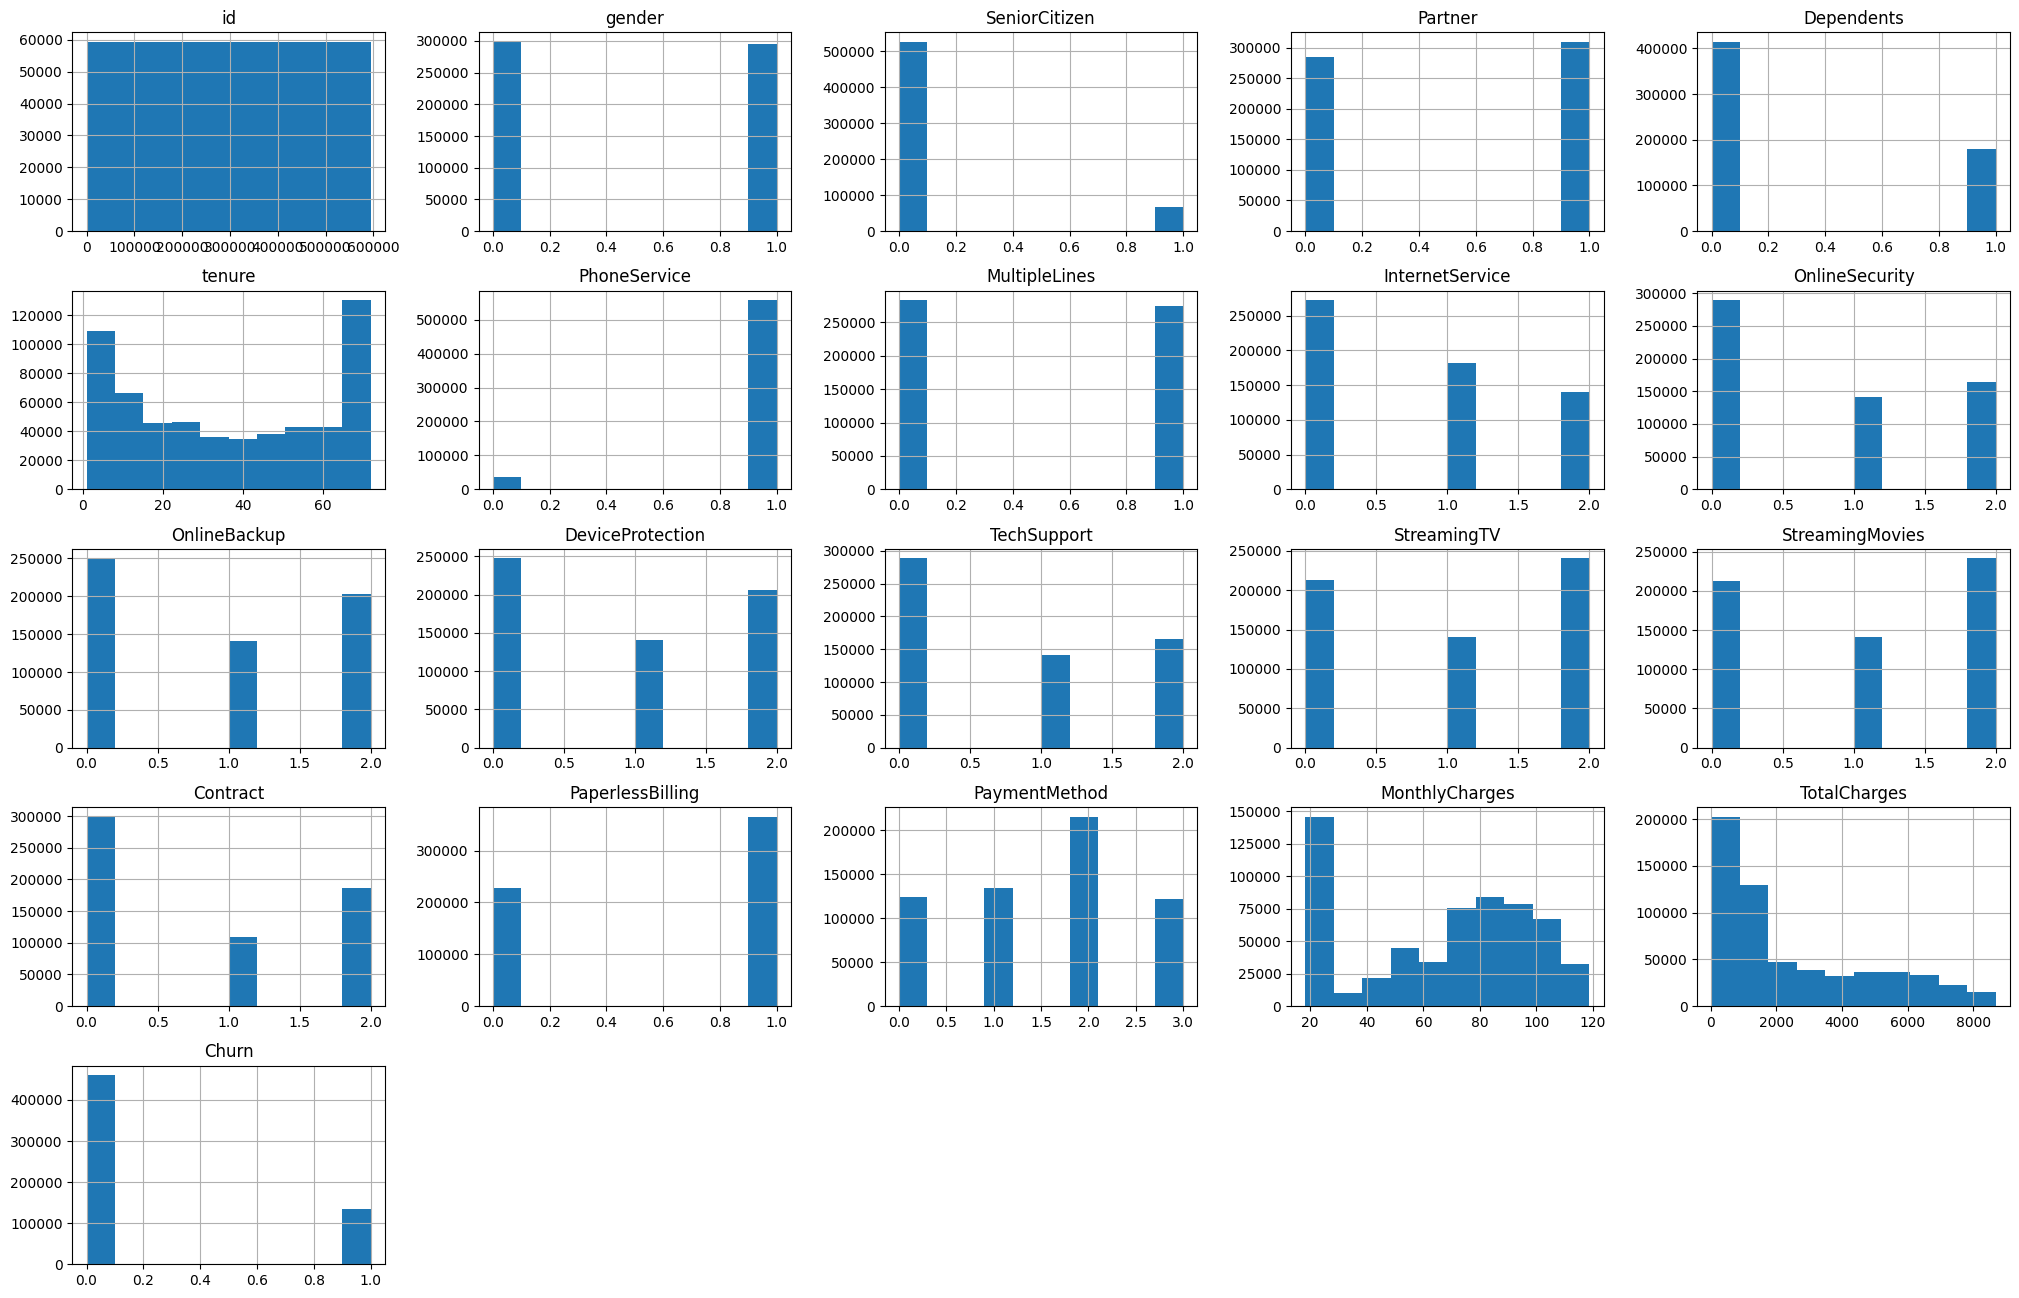

In [9]:
df.hist(sharex=False, sharey=False, layout=(5,5),figsize=(25, 16));

Looking at gender, both genders have fairly equal representation. It also seems a good amount of users do not have internet service. 

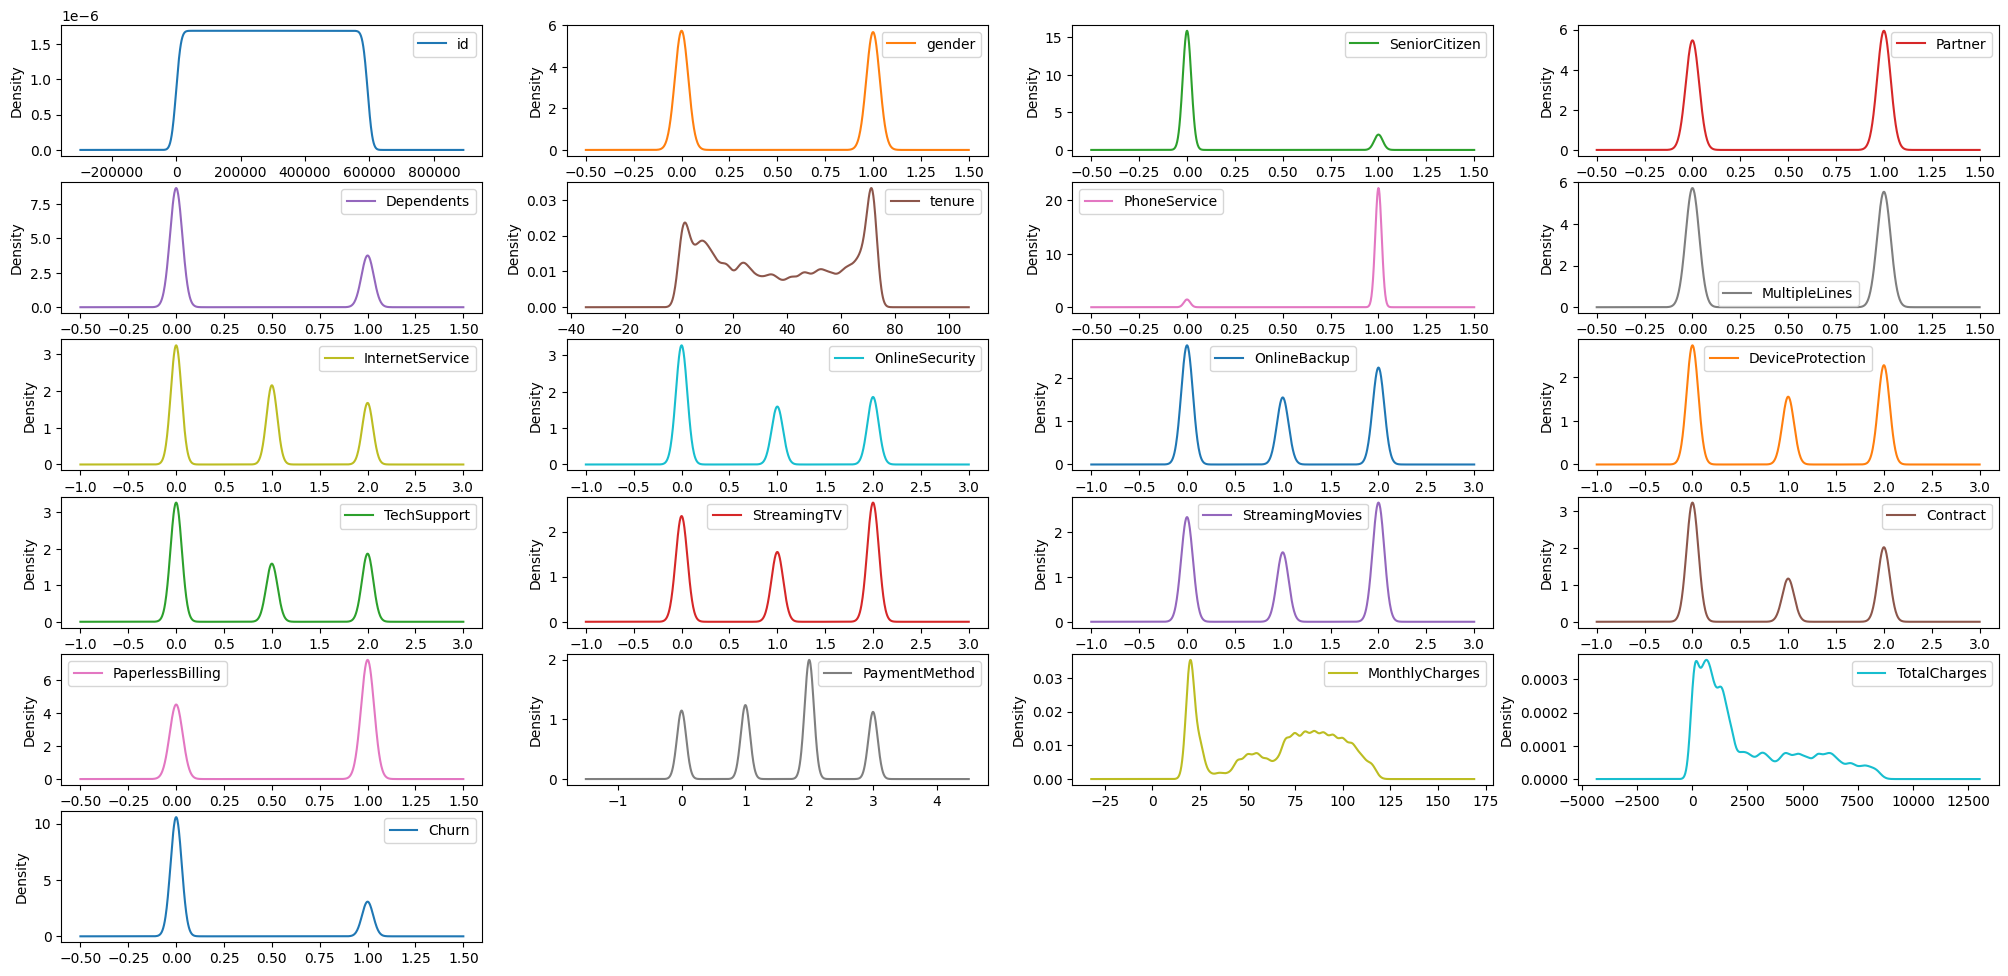

In [10]:
df.plot(kind='density',subplots=True, layout=(8,4), sharex=False, legend=True, figsize=(25, 16));

## Multimodal Data Visualizations

In [11]:
df.corr()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
id,1.000000,-0.001305,0.002035,0.008876,0.004912,0.019322,-0.001100,0.007813,-0.000331,0.008624,...,0.009316,0.008341,0.008692,0.009201,0.010734,-0.000988,0.004863,0.005729,0.014331,-0.012971
gender,-0.001305,1.000000,0.000103,-0.003706,0.000144,0.001504,-0.007558,-0.012246,0.009630,-0.003872,...,-0.006322,-0.005606,-0.007792,-0.007098,-0.000159,-0.005776,-0.007341,-0.013647,-0.006192,-0.006808
SeniorCitizen,0.002035,0.000103,1.000000,-0.026468,-0.215769,-0.084291,0.032778,0.153460,-0.273773,-0.174186,...,-0.049133,-0.177764,0.059644,0.058609,-0.198653,0.199061,0.128927,0.229079,0.042786,0.236362
Partner,0.008876,-0.003706,-0.026468,1.000000,0.532824,0.476774,0.029167,0.130281,0.096714,0.230230,...,0.239772,0.236551,0.174482,0.175499,0.411938,-0.082652,0.042347,0.045082,0.371255,-0.228212
Dependents,0.004912,0.000144,-0.215769,0.532824,1.000000,0.257342,-0.004184,-0.077792,0.289113,0.212659,...,0.127092,0.205413,0.030442,0.030624,0.345638,-0.211968,-0.099344,-0.203674,0.077273,-0.240369
tenure,0.019322,0.001504,-0.084291,0.476774,0.257342,1.000000,0.030192,0.270690,0.141860,0.420409,...,0.452993,0.446982,0.340384,0.341819,0.753957,-0.113104,0.126703,0.124043,0.769703,-0.418453
PhoneService,-0.001100,-0.007558,0.032778,0.029167,-0.004184,0.030192,1.000000,NaN,-0.070226,-0.035695,...,0.016588,-0.033259,0.064951,0.061894,0.024115,0.022072,0.021730,0.193100,0.090759,0.034843
MultipleLines,0.007813,-0.012246,0.153460,0.130281,-0.077792,0.270690,NaN,1.000000,-0.402295,-0.016560,...,0.158470,0.014192,0.262075,0.260163,0.043381,0.261198,0.243485,0.532479,0.471044,0.112692
InternetService,-0.000331,0.009630,-0.273773,0.096714,0.289113,0.141860,-0.070226,-0.402295,1.000000,0.296684,...,0.068914,0.279509,-0.118212,-0.117749,0.433977,-0.534388,-0.358657,-0.902826,-0.370470,-0.408363
OnlineSecurity,0.008624,-0.003872,-0.174186,0.230230,0.212659,0.420409,-0.035695,-0.016560,0.296684,1.000000,...,0.248883,0.382368,0.075685,0.077112,0.474751,-0.209798,-0.089356,-0.086686,0.308902,-0.356786


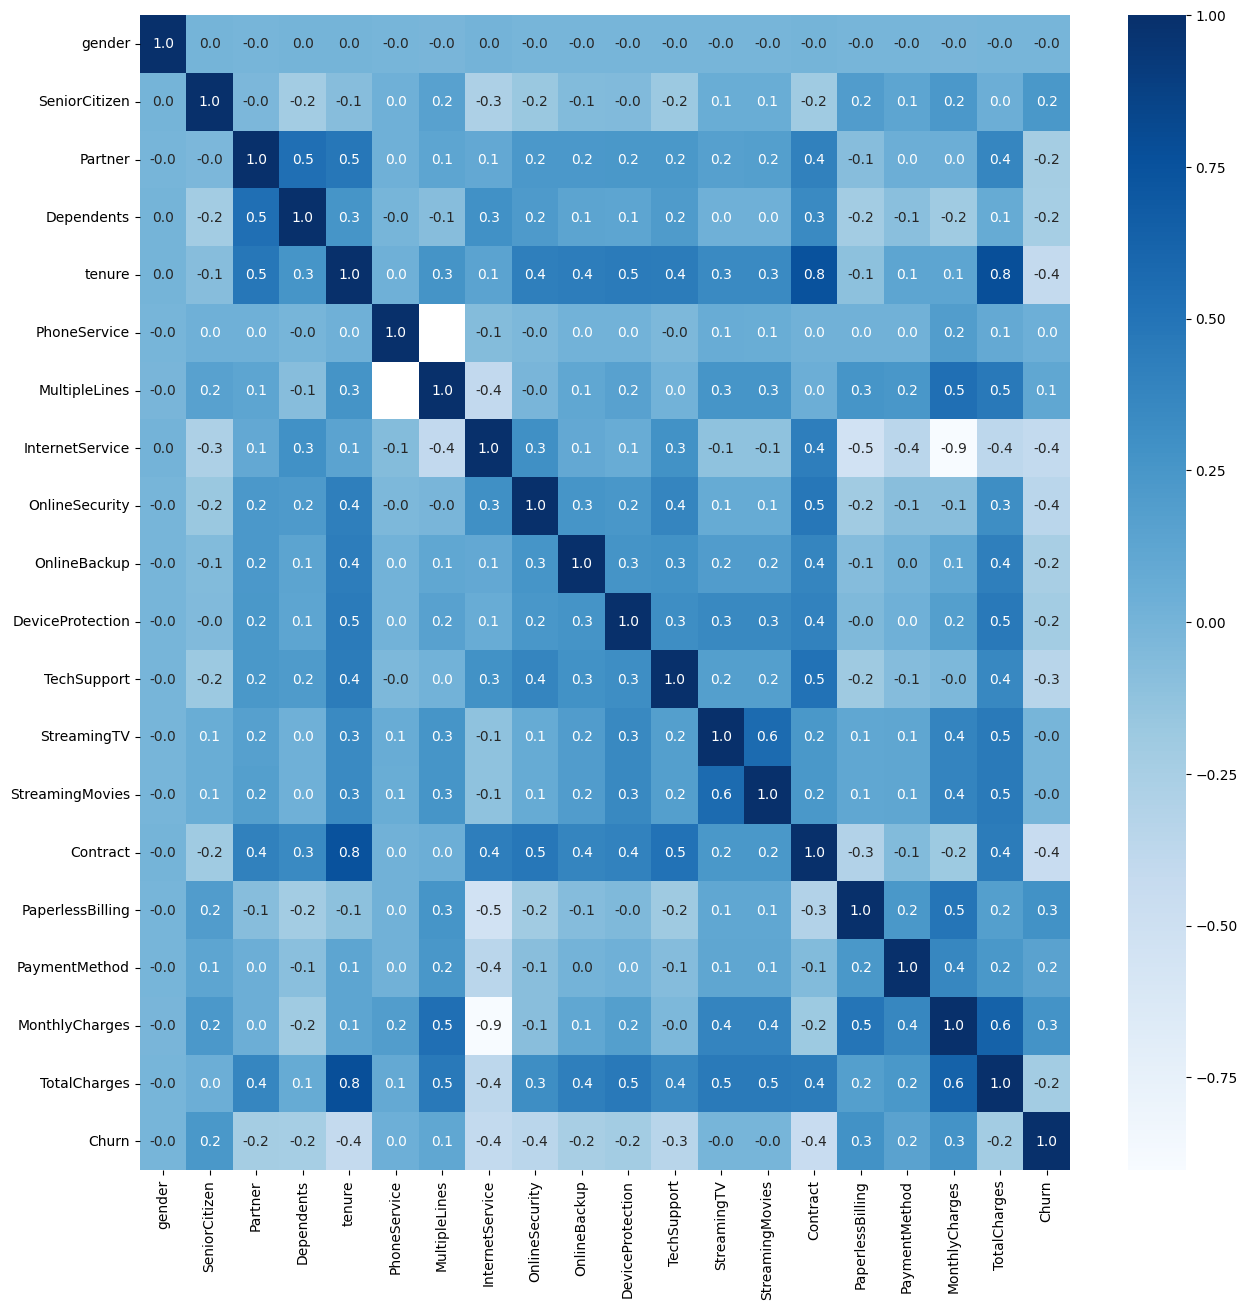

In [12]:
corr = df.drop(columns=['id']).corr()
plt.figure(figsize=(15,15))
sns.heatmap(corr, cmap="Blues",annot=True, fmt=".1f")
plt.show()

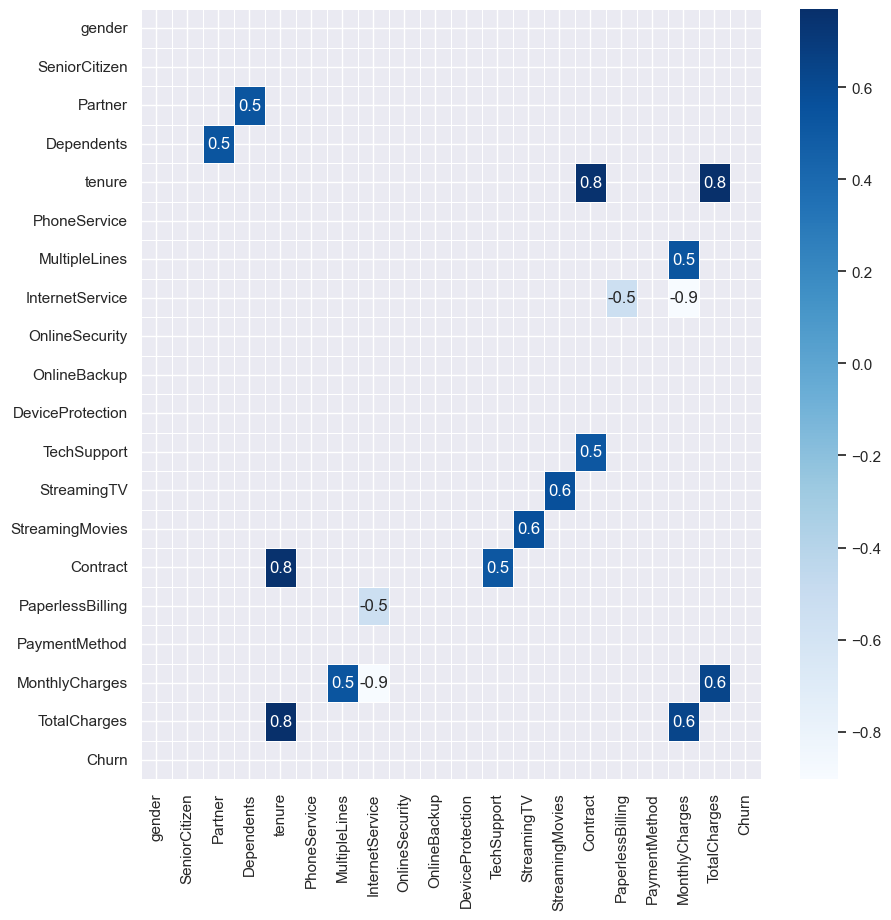

In [13]:
sns.set_theme()
filteredDf = corr[((corr >= .5) | (corr <= -.5)) & (corr !=1.000)]
plt.figure(figsize=(10,10))
sns.heatmap(filteredDf, cmap="Blues",annot=True, fmt=".1f", linewidths=0.5)
plt.show()

tenure has a strong relationship with TotalCharges and Contract. 
InternetService has a strong inverse relationship with MonthlyCharges. 